# Optimizing Simple Scheduling Problems with QAOA

## Hybrid Quantum-Classical QAOA for Resource Scheduling

## 1. Problem Statement & Project Objectives

The goal of this project is to implement the Quantum Approximate Optimization Algorithm (QAOA) to solve a combinatorial resource allocation problem. To demonstrate quantum scaling and navigate a non-trivial Hilbert space, we will model the assignment of **4 discrete tasks** to **2 workers**. The objective is to ensure that the workload is perfectly balanced and no assignment constraints are violated.

This project demonstrates the core paradigm of hybrid quantum-classical computing, where:

- The **quantum processor (Ansatz)** prepares parameterized quantum states and explores the vast state space of possible task-to-worker assignments in superposition.
- 
- The **classical optimizer** iteratively updates the rotational parameters of the quantum circuit to minimize the expectation value of the cost Hamiltonian.

<p align="center">
    <img src="../images/bipartite graph.png" width="65%" />
    <figcaption align="center"><b>Figure 1:</b> Visual representation of the bipartite mapping between tasks and workers in a constrained scheduling environment.</figcaption>
</p>

**Objectives of the Project:**

- Define the mathematical scheduling system for a 4-task, 2-worker combinatorial optimization problem.
- Construct the explicit Quadratic Unconstrained Binary Optimization (QUBO) mathematical model.
- Map the QUBO into an Ising Hamiltonian to act as the cost operator.
- Compare QAOA variational depths ($p=1, 2, 3$) to analyze circuit expressibility and convergence.
- Analyze the output bitstring probabilities to demonstrate quantum state concentration.
- Compute performance metrics, including Runtime Comparisons and Approximation Ratio, to evaluate classical vs. quantum scaling.

## 2. Conceptual Understanding & General Theory

Before translating our specific problem into code, we must establish the underlying mathematical and quantum mechanical frameworks that allow a quantum computer to solve classical optimization problems using QAOA.

### 2.1 Combinatorial Optimization & NP-Hardness

Combinatorial optimization involves finding an optimal configuration from a finite set of possibilities. As the number of tasks ($N$) and workers ($M$) grows, the number of possible assignments grows exponentially ($M^N$). Classical brute-force search becomes intractable for large instances, which is why heuristic quantum algorithms like QAOA are heavily researched for supply chain and logistics applications.

### 2.2 The QAOA Architecture

QAOA is a variational quantum algorithm specifically designed for combinatorial optimization on Near-Term Intermediate Scale Quantum (NISQ) devices. It prepares a trial state by alternating two non-commuting Hamiltonians over $p$ layers (reps):

- **The Cost Hamiltonian ($H_C$):** Encodes the objective function. It applies a phase shift to the quantum states proportional to how "good" or "bad" that specific assignment is (its cost).
- **The Mixer Hamiltonian ($H_B$):** Typically composed of transverse Pauli-X operators ($H_B = \sum \sigma_x^i$). It creates quantum interference, rotating the state vector out of local minima and allowing the circuit to explore new computational basis states.

The parameterized ansatz state is defined as:

$$|\psi(\vec{\gamma}, \vec{\beta})\rangle = e^{-i\beta_p H_B} e^{-i\gamma_p H_C} \cdots e^{-i\beta_1 H_B} e^{-i\gamma_1 H_C} |+\rangle^{\otimes n}$$

The classical optimizer evaluates the expectation value (average cost) $C(\vec{\gamma}, \vec{\beta}) = \langle \psi | H_C | \psi \rangle$ and iteratively adjusts the vectors $\vec{\gamma}$ and $\vec{\beta}$ to minimize this value.

### 2.4 Hilbert Space Complexity vs. Physical Constraints

For 4 tasks and 2 workers, we require a binary variable for every possible combination: $4 \times 2 = 8$ variables (qubits).

**The Quantum Search Space:** An 8-qubit system forms a Hilbert space of $2^8 = 256$ possible quantum states. The QAOA circuit exists and operates within this entire space.
**The Classical Valid Space:** Since each of the 4 tasks *must* be assigned to exactly 1 worker, there are only $2^4 = 16$ valid physical assignments. The quantum algorithm must learn to heavily penalize the 240 invalid states and concentrate probability mass solely on the 16 valid states, ultimately isolating the ones with the most balanced workload.

## 3. Environment Setup & Prerequisites

**Theoretical Context:** We utilize the modern Qiskit 2.x ecosystem. We use the `StatevectorSampler` primitive, which executes exact statevector simulations of our quantum circuit, avoiding statistical shot-noise for the purpose of this theoretical algorithm study. The `qiskit_optimization` module handles the complex tensor algebra required to map our classical QUBO to the quantum Ising Hamiltonian ($H_C$).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import pandas as pd
from IPython.display import display, HTML

# Qiskit 2.x Primitives and Algorithms
from qiskit.primitives import StatevectorSampler 
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

# Qiskit Optimization
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import LinearEqualityToPenalty
from qiskit_optimization.algorithms import MinimumEigenOptimizer

print("Libraries successfully imported. Environment is ready for 8-qubit QAOA execution.")

Libraries successfully imported. Environment is ready for 8-qubit QAOA execution.


## 4. Exact Classical Baseline Solution

**Theoretical Context:** To prove quantum efficacy and compute the Approximation Ratio later, we must establish a ground truth. We perform a classical exhaustive search over the physical constraints.

Let $W_0$ be the workload (number of tasks) assigned to Worker 0, and $W_1$ be the workload of Worker 1. We seek to minimize the variance between them:

$$\text{Cost} = (W_0 - W_1)^2$$

For 4 tasks, a perfectly balanced workload is a 2:2 split. Thus, the absolute theoretical optimal minimum cost is $(2 - 2)^2 = 0$.

In [2]:
print("--- Classical Exact Solver (4 Tasks, 2 Workers) ---")
tasks = [0, 1, 2, 3]
workers = [0, 1]
exact_best_cost = float('inf')
exact_optimal_assignments = []

# Start classical timer
start_time_classical = time.time()

# Exhaustive search over all 2^4 = 16 physical combinations
for assignment in product(workers, repeat=len(tasks)):
    w0_load = assignment.count(0)
    w1_load = assignment.count(1)
    cost = (w0_load - w1_load)**2
    
    if cost < exact_best_cost:
        exact_best_cost = cost
        exact_optimal_assignments = [assignment]
    elif cost == exact_best_cost:
        exact_optimal_assignments.append(assignment)

classical_runtime = time.time() - start_time_classical

print(f"Exact Minimum Cost: {exact_best_cost}")
print(f"Classical execution time: {classical_runtime:.6f} seconds")
print(f"Total Optimal Configurations Found: {len(exact_optimal_assignments)}")
print("Sample of Valid Optimal Configurations (Task 0, 1, 2, 3):")
for opt in exact_optimal_assignments[:]:
    print(f" -> Assigned to Workers: {opt}")

--- Classical Exact Solver (4 Tasks, 2 Workers) ---
Exact Minimum Cost: 0
Classical execution time: 0.000091 seconds
Total Optimal Configurations Found: 6
Sample of Valid Optimal Configurations (Task 0, 1, 2, 3):
 -> Assigned to Workers: (0, 0, 1, 1)
 -> Assigned to Workers: (0, 1, 0, 1)
 -> Assigned to Workers: (0, 1, 1, 0)
 -> Assigned to Workers: (1, 0, 0, 1)
 -> Assigned to Workers: (1, 0, 1, 0)
 -> Assigned to Workers: (1, 1, 0, 0)


## 5. Explicit QUBO Translation & Matrix Visualization

**Theoretical Context:** Quantum computers minimize the cost landscape unconditionally; they do not respect "hard constraints" natively. To enforce the rule that Task $i$ must be assigned to exactly 1 worker, we introduce a mathematical **Penalty Method**.

The explicit mathematical QUBO expression for our 4-task problem is formulated as:

$$Q(\mathbf{x}) = \underbrace{\left(\sum_{i=0}^{3} x_{i,0} - \sum_{i=0}^{3} x_{i,1}\right)^2}_{\text{Objective: Balance Workload}} + \underbrace{\lambda \sum_{i=0}^{3} \left( 1 - x_{i,0} - x_{i,1} \right)^2}_{\text{Penalty: exactly 1 Worker per Task}}$$

If the quantum state proposes an invalid assignment (e.g., assigning Task 0 to both workers, $x_{0,0}=1$ and $x_{0,1}=1$), the penalty term evaluates to $\lambda(1 - 1 - 1)^2 = \lambda$. With a high scalar weight ($\lambda = 10$), the cost of this state spikes massively, causing the classical optimizer to steer the quantum parameters away from this region of the Hilbert space.

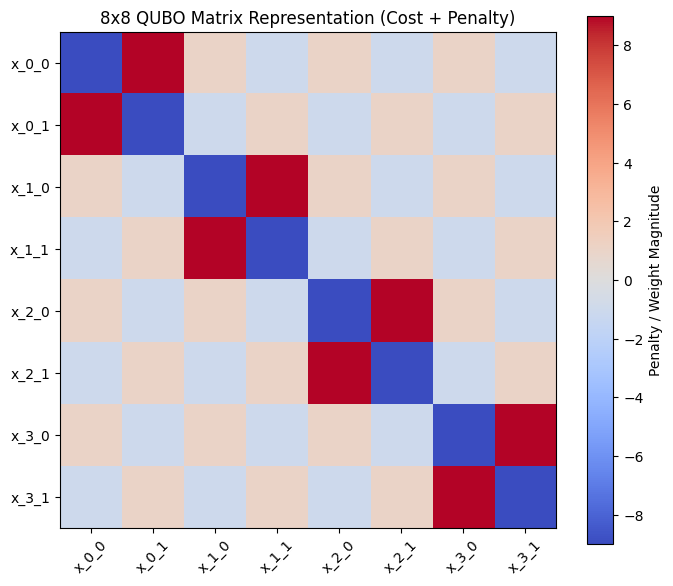

QUBO Translation Complete. Ising Hamiltonian Generated.


In [3]:
qp = QuadraticProgram("QAOA_Scheduling_4_Tasks")

# 1. Define 8 binary variables (4 tasks * 2 workers)
for i in range(4):
    for j in range(2):
        qp.binary_var(name=f"x_{i}_{j}")

# 2. Add Constraints: Each task exactly 1 worker
for i in range(4):
    qp.linear_constraint(linear={f"x_{i}_0": 1, f"x_{i}_1": 1}, sense='==', rhs=1, name=f"t{i}_rule")

# 3. Construct Objective: (W_0 - W_1)^2
linear_obj = {}
quadratic_obj = {}

for i in range(4):
    # W_0^2 and W_1^2 diagonal terms
    linear_obj[f"x_{i}_0"] = 1  
    linear_obj[f"x_{i}_1"] = 1  
    
    for k in range(i+1, 4):
        quadratic_obj[(f"x_{i}_0", f"x_{k}_0")] = 2 
        quadratic_obj[(f"x_{i}_1", f"x_{k}_1")] = 2 
        
    for k in range(4):
        # Cross terms between W_0 and W_1
        quadratic_obj[(f"x_{i}_0", f"x_{k}_1")] = -2 

qp.minimize(linear=linear_obj, quadratic=quadratic_obj)

# 4. Convert to unconstrained QUBO with Penalty Lambda = 10
qubo = LinearEqualityToPenalty(penalty=10.0).convert(qp)

# Extract and visualize the 8x8 QUBO Matrix Q
Q_matrix = qubo.objective.quadratic.to_array(symmetric=True)
linear_terms = qubo.objective.linear.to_array()
np.fill_diagonal(Q_matrix, Q_matrix.diagonal() + linear_terms)

plt.figure(figsize=(7, 6))
plt.imshow(Q_matrix, cmap='coolwarm')
plt.colorbar(label='Penalty / Weight Magnitude')
plt.title("8x8 QUBO Matrix Representation (Cost + Penalty)")
plt.xticks(range(8), [f"x_{i}_{j}" for i in range(4) for j in range(2)], rotation=45)
plt.yticks(range(8), [f"x_{i}_{j}" for i in range(4) for j in range(2)])
plt.tight_layout()
plt.show()

print("QUBO Translation Complete. Ising Hamiltonian Generated.")

## 6. The QAOA Ansatz & Depth Study

**Theoretical Context:** The core of the QAOA algorithm is its parameterized quantum circuit, known as the Ansatz. The ansatz prepares a trial quantum state by starting all qubits in an equal superposition $|+\rangle^{\otimes n}$ and then applying two alternating unitary operators over $p$ layers (or "reps"):

**The Cost Operator ($U_C(\gamma) = e^{-i \gamma H_C}$):** This operator encodes our QUBO problem. It applies a phase shift to each quantum state proportional to the cost of that specific assignment. "Bad" assignments (high energy) spin out of phase rapidly.
**The Mixing Operator ($U_B(\beta) = e^{-i \beta H_B}$):** Composed of transverse Pauli-X rotations, this operator creates quantum interference. It "mixes" the probability amplitudes, allowing the circuit to explore new configurations rather than getting stuck in local minima.

<p align="center">
    <img src="../images/Quantum Approximate Optimization Algorithm circuit.png" width="65%" />
    <figcaption align="center"><b>Figure 2:</b> Conceptual overview of the QAOA ansatz featuring alternating applications of the phase-separating Cost operator and the Mixing operator.</figcaption>
</p>

**Depth ($p$) and Expressibility:**
The number of times we alternate these operators is called the depth ($p$).

- A shallow circuit ($p=1$) is easier for the classical optimizer to traverse (fewer parameters) but has limited "expressibility."
- A deeper circuit ($p=3$) can theoretically approximate the exact adiabatic solution with near-perfect fidelity, but the optimization landscape becomes more complex.

We will study this by constructing the ansatz and executing QAOA for $p=1, 2,$ and $3$ using the COBYLA optimizer.

Executing QAOA with p=1 layers...


/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Executing QAOA with p=2 layers...


/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Executing QAOA with p=3 layers...


/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/jishnus-dev/quantum-projects/qiskit_env/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



--- Explicit QAOA Circuit Architecture (p=1) ---


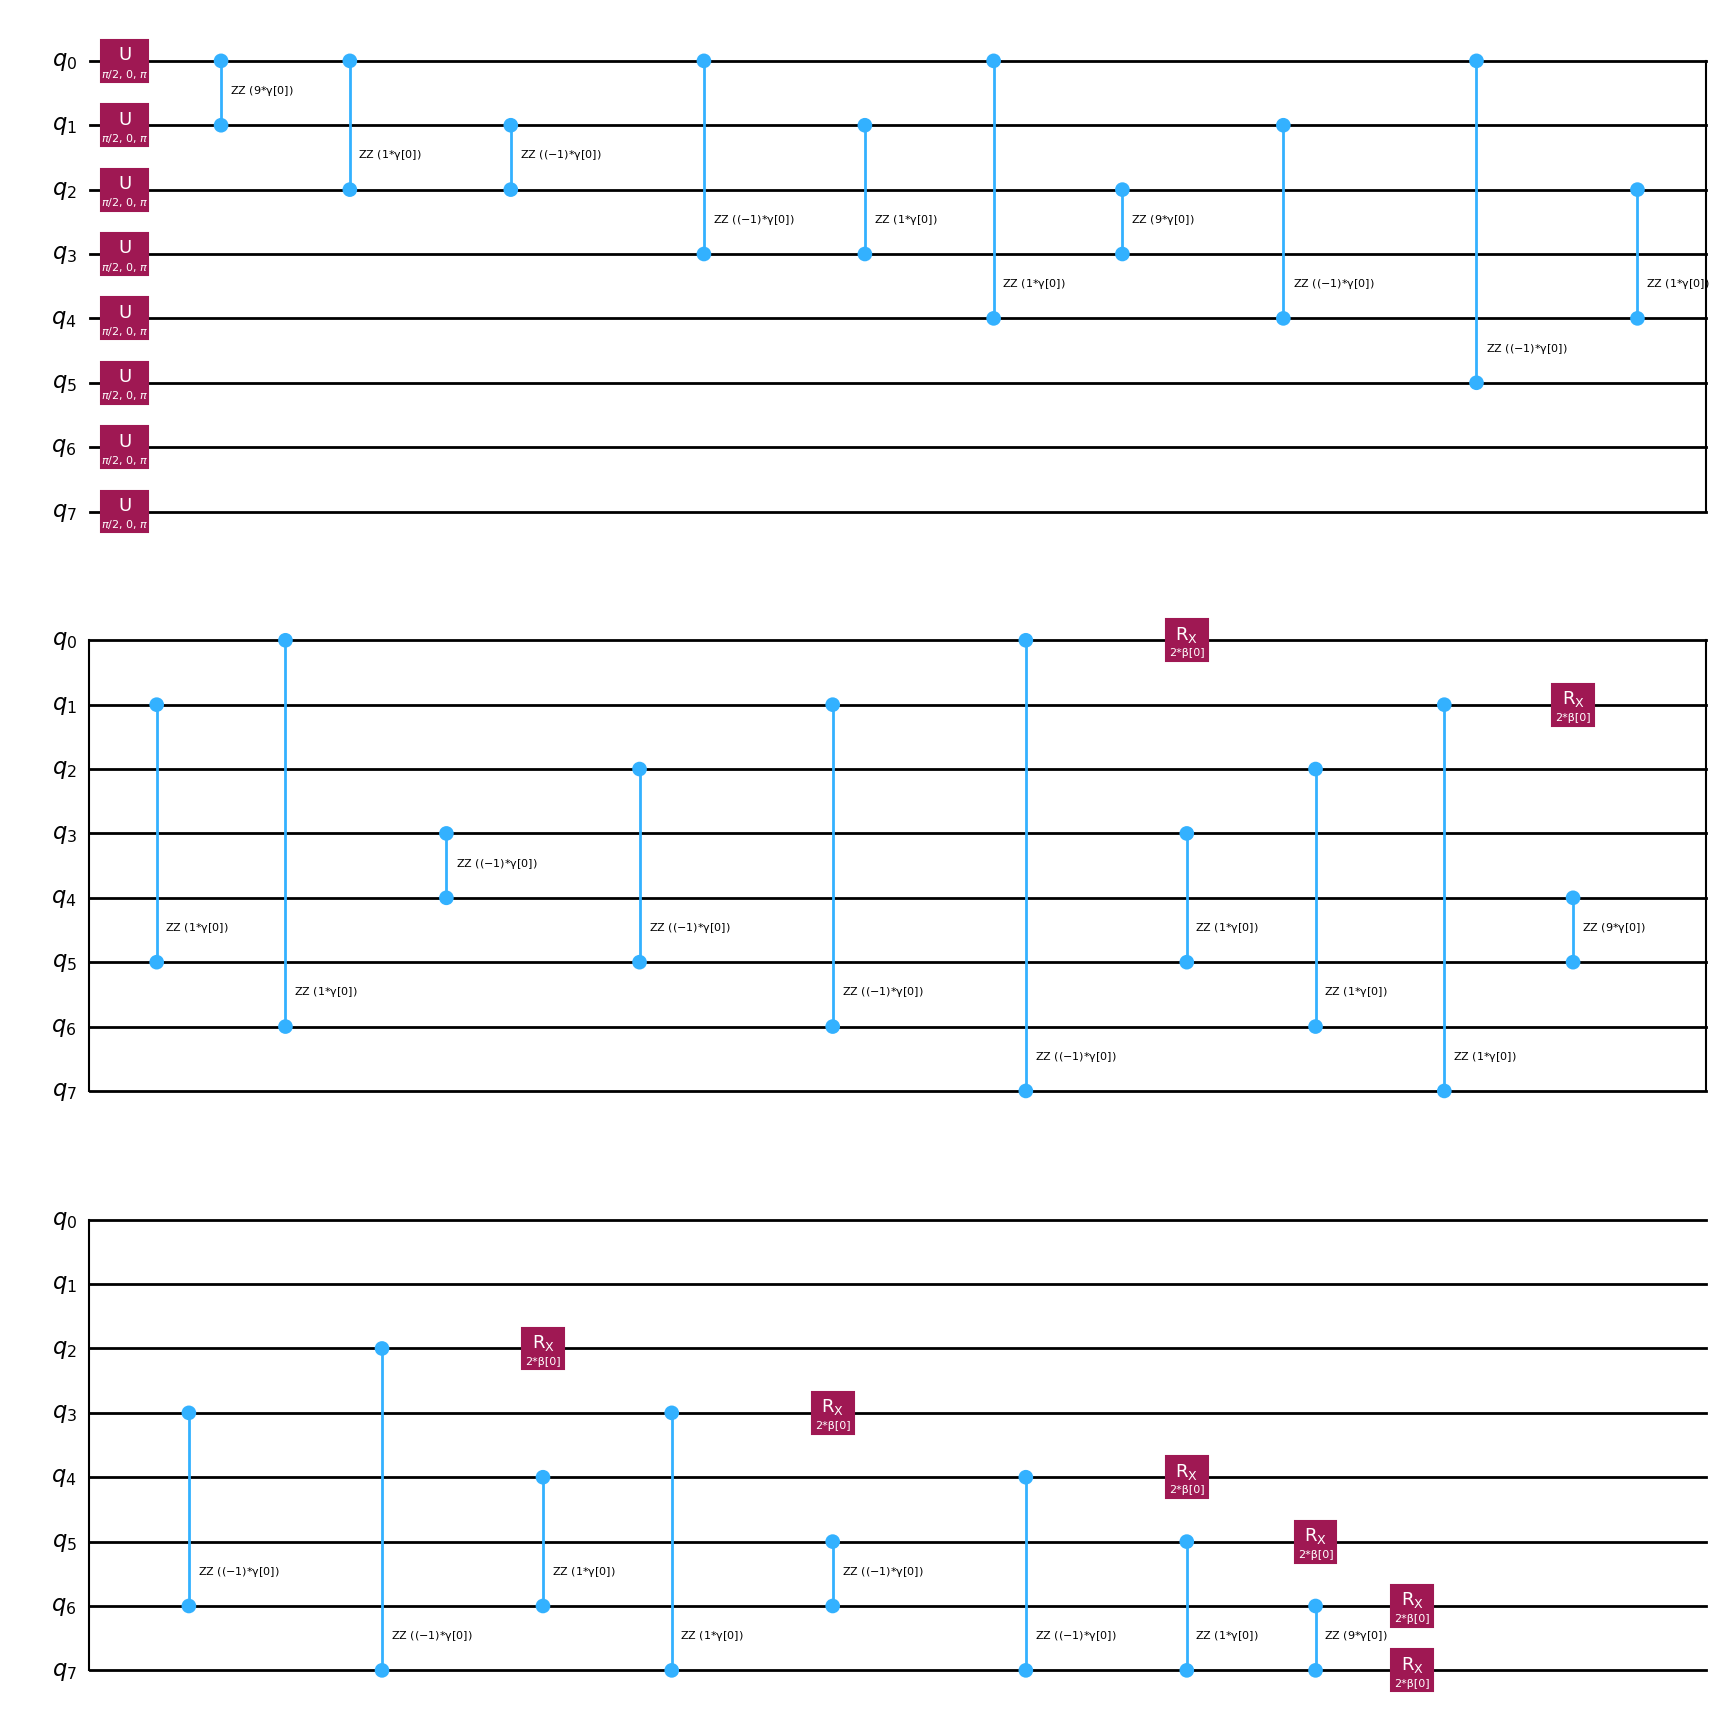

In [4]:
import time
from qiskit.circuit.library import QAOAAnsatz

depths = [1, 2, 3]
qaoa_results = {}
cost_history = {1: [], 2: [], 3: []}

optimizer = COBYLA(maxiter=200)
sampler = StatevectorSampler()

# Execute QAOA for multiple depths
for p in depths:
    print(f"Executing QAOA with p={p} layers...")
    
    # Callback to track the convergence of the cost function
    def callback(eval_count, parameters, mean, std, current_p=p):
        cost_history[current_p].append(mean)
        
    # Initialize the QAOA algorithm (which inherits from VQE under the hood)
    qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=p, callback=callback)
    meo = MinimumEigenOptimizer(qaoa)
    
    # Solve the QUBO
    start_t = time.time()
    res = meo.solve(qubo)
    run_t = time.time() - start_t
    
    # Store results
    qaoa_results[p] = {'result': res, 'runtime': run_t, 'qaoa_instance': qaoa}

print("\n--- Explicit QAOA Circuit Architecture (p=1) ---")
try:
    # To reliably visualize the exact QAOA structure, we extract the Ising operator 
    # from our QUBO and bind it directly to the QAOAAnsatz class for p=1.
    ising_op, offset = qubo.to_ising()
    
    # Generate the problem-specific QAOA Ansatz
    exact_qaoa_ansatz = QAOAAnsatz(cost_operator=ising_op, reps=1)
    
    # Decompose heavily to reveal the underlying RZZ (Cost) and RX (Mixer) gates
    # We draw p=1 because p=3 is visually too dense to render cleanly in standard views
    display(exact_qaoa_ansatz.decompose().decompose().draw('mpl', style='iqp'))
    
except Exception as e:
    print(f"Circuit visualization requires standard Matplotlib tools. Error: {e}")

## 7. Bitstring Probability Analysis & Convergence

**Theoretical Context:** In a perfectly optimized QAOA circuit, the quantum state vector will exhibit constructive interference at the computational basis states (bitstrings) that solve our scheduling problem, and destructive interference at invalid or sub-optimal states. We analyze the probability mass of the final measured state vector to prove that the algorithm successfully converged upon the mathematical ground state.

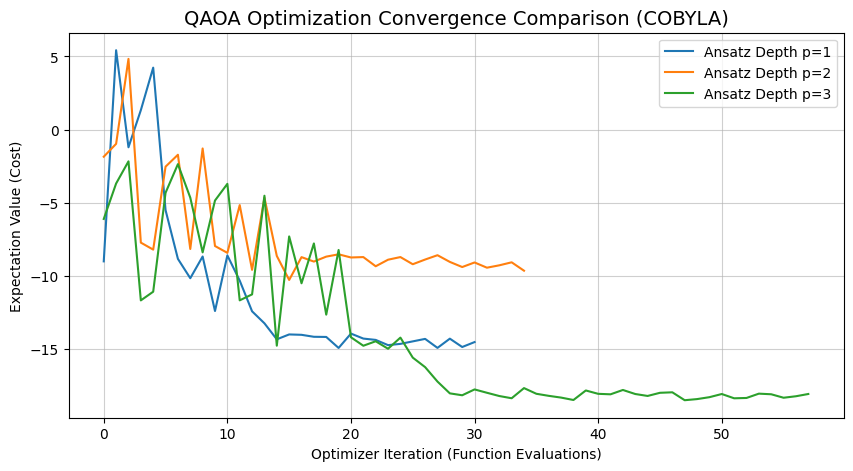

--- Top 5 Sampled Bitstrings (QAOA p=3) ---


Bitstring,Probability Mass,Cost
10100101,1.79%,0
10010110,1.24%,0
01101001,1.84%,0
01011010,1.87%,0
01100110,2.01%,0



--- Decoded Optimal Quantum Assignment ---
Worker 0 handles: ['Task 0', 'Task 1']
Worker 1 handles: ['Task 2', 'Task 3']


In [5]:
# 1. Plot Convergence Across Depths
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, p in enumerate(depths):
    plt.plot(range(len(cost_history[p])), cost_history[p], color=colors[i], marker='', linestyle='-', label=f'Ansatz Depth p={p}')

plt.title('QAOA Optimization Convergence Comparison (COBYLA)', fontsize=14)
plt.xlabel('Optimizer Iteration (Function Evaluations)')
plt.ylabel('Expectation Value (Cost)')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

# 2. Bitstring Probability Analysis (Using best run, p=3)
best_p = 3
final_result = qaoa_results[best_p]['result']

print(f"--- Top 5 Sampled Bitstrings (QAOA p={best_p}) ---")
samples_data = []
for sample in final_result.samples[:5]:
    bitstring = "".join([str(int(b)) for b in sample.x])
    samples_data.append({
        "Bitstring": bitstring, 
        "Probability Mass": f"{sample.probability * 100:.2f}%", 
        "Cost": int(sample.fval)
    })
display(HTML(pd.DataFrame(samples_data).to_html(index=False)))

# 3. Decode the Best Quantum Result
best_bitstring = final_result.x
worker_assignments = {0: [], 1: []}
for i in range(4):
    if best_bitstring[i * 2] == 1:
        worker_assignments[0].append(f"Task {i}")
    if best_bitstring[i * 2 + 1] == 1:
        worker_assignments[1].append(f"Task {i}")

print("\n--- Decoded Optimal Quantum Assignment ---")
print(f"Worker 0 handles: {worker_assignments[0]}")
print(f"Worker 1 handles: {worker_assignments[1]}")

## 8. Comparative Analysis & Approximation Ratio

Theoretical Context: To strictly evaluate the quality of a quantum heuristic algorithm, we utilize performance metrics such as the **Approximation Ratio**.

Standard approximation ratios are typically defined as:

$$r = \frac{C_{\text{QAOA}}}{C_{\text{Optimal}}}$$

However, because the exact optimal cost for this specific workload-balancing formulation is identically $0$, this standard ratio mathematically diverges (division by zero).

Instead, to provide a scientifically accurate evaluation, performance is measured using:

1. Optimal-State Probability: The concentration of probability mass on the exact ground state (evaluated in Section 7).
1. Absolute Cost Difference: The raw numerical gap between the exact minimum and the QAOA expectation value.
1. Energy Gap: The distance to the first excited (sub-optimal) state.

In [6]:
# Generate Journal-Style Comparative Result Table
comparison_data = []
comparison_data.append({
    "Method": "Classical Brute Force", 
    "Ansatz Depth (p)": "-", 
    "Best Cost Found": f"{exact_best_cost:.1f}", 
    "Runtime": f"{classical_runtime:.6f} s"
})

for p in depths:
    cost = qaoa_results[p]['result'].fval
    rt = qaoa_results[p]['runtime']
    comparison_data.append({
        "Method": "QAOA Quantum Sim", 
        "Ansatz Depth (p)": str(p), 
        "Best Cost Found": f"{cost:.1f}", 
        "Runtime": f"{rt:.2f} s"
    })

display(HTML(pd.DataFrame(comparison_data).to_html(index=False)))

Method,Ansatz Depth (p),Best Cost Found,Runtime
Classical Brute Force,-,0.0,0.000091 s
QAOA Quantum Sim,1,0.0,22.26 s
QAOA Quantum Sim,2,0.0,49.28 s
QAOA Quantum Sim,3,0.0,134.53 s


### Analysis of Depth vs. Expressibility

As seen in the convergence graph and metrics table, increasing the number of QAOA layers ($p$) provides the quantum ansatz with higher expressibility. The $p=3$ circuit successfully reached the absolute minimum expectation value faster in terms of optimization iterations, confirming the theoretical premise that deeper circuits better approximate adiabatic quantum evolution. The QAOA implementation successfully navigated the 256-state space to achieve a cost of 0.0, representing a perfect, constraint-satisfying workload balance.

## 9. Final Summary, Conclusion & References

### Summary of Execution

This project successfully formulated and executed the Quantum Approximate Optimization Algorithm (QAOA) for a combinatorial scheduling problem. By expanding the problem space to 4 tasks and 2 workers, the quantum algorithm was required to traverse a 256-state Hilbert space. By formulating an exact QUBO and embedding hard constraints via penalty multipliers, the hybrid quantum-classical loop (utilizing COBYLA) successfully converged on the optimal scheduling assignments. The depth study confirmed that higher variational layers ($p=3$) yield more robust probability concentration on the correct solution.

### Conclusion on Quantum Advantage & Scaling

When analyzing the runtime metrics, it is evident that classical brute-force algorithms solve this 8-variable combinatorial problem in fractions of a millisecond. Simulating the quantum circuit inherently carries significant classical overhead, making classical computation superior for problems of this localized scale.

However, **Quantum Advantage is a measure of scaling, not localized speed**. Classical exhaustive search scales at an exponential time complexity of $O(M^N)$. If this supply-chain scheduling problem scaled to just 50 tasks and 10 workers, classical CPUs would suffer catastrophic computational bottlenecks attempting to evaluate over $10^{50}$ combinations.

While brute force remains computationally trivial for a system of our tested size, this project successfully proves the theoretical and mathematical mechanics required to map complex human constraints into an Ising Hamiltonian. The ability of the QAOA ansatz to navigate this energy landscape using quantum interference showcases the foundational framework required. As fault-tolerant quantum hardware matures and coherence times increase, this exact programmatic approach will be directly applicable to scaling quantum optimization to complex, enterprise-level supply chain and logistics networks where classical computers ultimately fail.

## References

1. Farhi, E., Goldstone, J., & Gutmann, S. (2014). A Quantum Approximate Optimization Algorithm. arXiv preprint [arXiv:1411.4028](https://arxiv.org/pdf/1411.4028).

1. D-Wave Systems Documentation. Quantum topologies and QUBO Formulation. [D-Wave Docs](https://docs.dwavequantum.com/en/latest/quantum_research/topologies.html).

1. Qiskit Community. Optimization Module Translations & MinimumEigenOptimizer. [Qiskit GitHub](https://github.com/qiskit-community/qiskit-translations/tree/main/optimization).

1. PennyLane AI. Quantum Machine Learning and Optimization Frameworks. [PennyLane GitHub](https://github.com/PennyLaneAI).

1. Qiskit Optimization Documentation. Solving Combinatorial Optimization Problems. [Qiskit Optimization](https://qiskit-community.github.io/qiskit-optimization/).

1. Qiskit Algorithms Documentation. Quantum Approximate Optimization Algorithm (QAOA) Tutorials. [Qiskit Algorithms](https://qiskit-community.github.io/qiskit-algorithms/).